# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [1]:
from pathlib import Path

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw')
[(story.splitlines()[0], len(story)) for story in stories]

[('THE DAW IN BORROWED FEATHERS', 859)]

In [2]:
len(stories), [story.splitlines()[0] for story in stories]

(1, ['THE DAW IN BORROWED FEATHERS'])

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [3]:
graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)
traces = graphicalizer.fit([stories[0]]).transform_with_trace([stories[0]])
trace = traces[0]
[(p.text, p.proposition_id) for p in trace.propositions]

[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-0] processing document: chars=859
[document-0] segment: 1 -> 1 | 0.1 ms | input_chars=859, chunk_chars=859
[document-0 chunk-0] compiling semantic stages
[document-0 chunk-0] summarize: 1 -> 1 | 2014.1 ms | input_chars=859, output_chars=497
[document-0 chunk-0] normalize: 1 -> 1 | 1780.0 ms | input_chars=497, output_chars=728
[document-0 chunk-0] decompose: 1 -> 12 | 15733.1 ms
[document-0 chunk-0] triple: 12 -> 12 | 10332.6 ms
[document-0] integrate: 12 -> 12 | 0.3 ms | nodes=16, edges=12
[document-0] total: 1 -> 1 | 29860.4 ms | chunks=1, propositions=12, triples=12, nodes=16, edges=12


[('A jackdaw is characterized by vanity.', 'document-0:chunk-0:p1'),
 ('The jackdaw adorned itself with colorful peacock feathers.',
  'document-0:chunk-0:p2'),
 ('The jackdaw wanted to appear as beautiful as a peacock.',
  'document-0:chunk-0:p3'),
 ('The jackdaw wanted to be accepted among the peacocks.',
  'document-0:chunk-0:p4'),
 ('The jackdaw interacted with the peacocks by attempting to join their group.',
  'document-0:chunk-0:p5'),
 ("The jackdaw's false appearance and affected behavior revealed its sham.",
  'document-0:chunk-0:p6'),
 ('The peacocks attacked the jackdaw as a consequence of the revealed sham.',
  'document-0:chunk-0:p7'),
 ('The attack removed the borrowed feathers from the jackdaw.',
  'document-0:chunk-0:p8'),
 ('The jackdaw was driven away by the peacocks.', 'document-0:chunk-0:p9'),
 ('When the jackdaw returned to its kind, the other jackdaws rejected it.',
  'document-0:chunk-0:p10'),
 ('The other jackdaws treated the jackdaw with contempt due to its pre

In [4]:
graphicalizer.display(trace.graph, mode="dynamic")

<IPython.core.display.Javascript object>

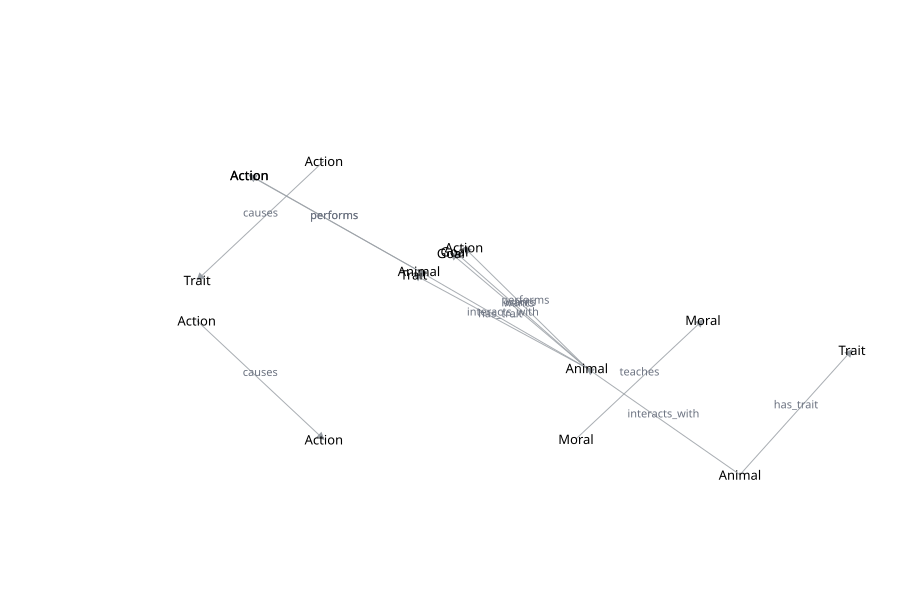

In [5]:
# Deterministic alternative: NetworkX Kamada-Kawai layout.
graphicalizer.display(trace.graph, mode="static")